# RAGBench `emanual` — Corpus & Chunking Analysis

Examines the raw corpus and ground truth parquet files to understand:
- Document structure and text length distribution
- How `chunk_size=500` interacts with actual document sizes
- Which documents get split (and where mid-word cuts happen)
- Ground truth supporting document coverage

In [2]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

DATASET_DIR = Path("../local/datasets/ragbench_emanual")

corpus = pd.read_parquet(DATASET_DIR / "corpus.parquet")
ground_truth = pd.read_parquet(DATASET_DIR / "ground_truth.parquet")

print(f"Corpus:       {corpus.shape}")
print(f"Ground truth: {ground_truth.shape}")

Corpus:       (102, 3)
Ground truth: (132, 6)


## Corpus — structure and samples

In [3]:
print("Columns:", corpus.columns.tolist())
corpus.head(5)

Columns: ['id', 'text', 'metadata']


,id,text,metadata
0,doc_b9949307f0ca,Changing the content and settings for Ambient ...,{'source': 'rungalileo/ragbench/emanual'}
1,doc_85d327c2a8bc,Using the Ambient Mode. Learn about the functi...,{'source': 'rungalileo/ragbench/emanual'}
2,doc_85810cf5f9fa,Checking digital channel signal info and stren...,{'source': 'rungalileo/ragbench/emanual'}
3,doc_ea8f8c2f9f4f,Viewing Broadcast Information at a Glance. See...,{'source': 'rungalileo/ragbench/emanual'}
4,doc_3ad5c54723b4,Finding the contact information for service. S...,{'source': 'rungalileo/ragbench/emanual'}


In [4]:
corpus["text_len"] = corpus["text"].str.len()

print(corpus["text_len"].describe().round(1))

count     102.0
mean      849.7
std       927.5
min        68.0
25%       272.0
50%       569.0
75%      1139.5
max      5577.0
Name: text_len, dtype: float64


## Text-length distribution

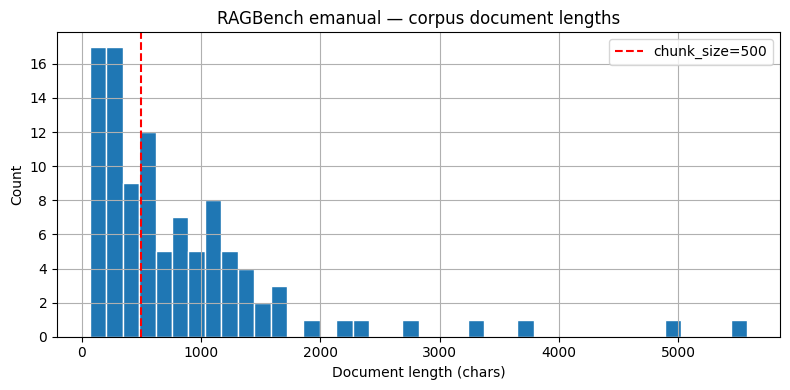

Docs ≤ 500 chars (single-chunk pass-through): 46/102 (45.1%)
Docs >  500 chars (will be split):            56/102 (54.9%)


In [5]:
CHUNK_SIZE = 500

fig, ax = plt.subplots(figsize=(8, 4))
corpus["text_len"].hist(bins=40, ax=ax, edgecolor="white")
ax.axvline(CHUNK_SIZE, color="red", linestyle="--", label=f"chunk_size={CHUNK_SIZE}")
ax.set_xlabel("Document length (chars)")
ax.set_ylabel("Count")
ax.set_title("RAGBench emanual — corpus document lengths")
ax.legend()
plt.tight_layout()
plt.show()

under = (corpus["text_len"] <= CHUNK_SIZE).sum()
over  = (corpus["text_len"] >  CHUNK_SIZE).sum()
print(f"Docs ≤ {CHUNK_SIZE} chars (single-chunk pass-through): {under}/{len(corpus)} ({100*under/len(corpus):.1f}%)")
print(f"Docs >  {CHUNK_SIZE} chars (will be split):            {over}/{len(corpus)} ({100*over/len(corpus):.1f}%)")

## Documents that get split (mid-word cut examples)

Simulate `_chunk_fixed` from `embedding.py` with `chunk_size=500, chunk_overlap=64`.

In [6]:
def chunk_fixed(doc_id: str, text: str, chunk_size: int = 500, chunk_overlap: int = 64):
    """Mirrors EmbeddingService._chunk_fixed (word-boundary-aware)."""
    chunks = []
    start, idx = 0, 0
    while start < len(text):
        end = min(start + chunk_size, len(text))
        # Snap to nearest whitespace to avoid mid-word cuts
        if end < len(text):
            last_space = text.rfind(" ", start, end)
            if last_space > start:
                end = last_space + 1
        chunk_text = text[start:end]
        if chunk_text.strip():
            chunks.append({"doc_id": doc_id, "chunk_index": idx,
                           "start": start, "end": end, "text": chunk_text})
            idx += 1
        next_start = end - chunk_overlap
        if next_start <= start:
            next_start = end
        start = next_start
        if end >= len(text):
            break
    return chunks


all_chunks = []
for _, row in corpus.iterrows():
    all_chunks.extend(chunk_fixed(row["id"], row["text"]))

chunks_df = pd.DataFrame(all_chunks)
chunks_df["chunk_len"] = chunks_df["text"].str.len()

total_chunks = len(chunks_df)
split_docs   = (corpus["text_len"] > CHUNK_SIZE).sum()
non_first    = chunks_df[chunks_df["chunk_index"] > 0]

print(f"Total chunks produced: {total_chunks}")
print(f"Docs that produced >1 chunk: {split_docs}")
print(f"Chunks that start mid-document (chunk_index > 0): {len(non_first)}")
print()
print("Chunk length stats:")
print(chunks_df["chunk_len"].describe().round(1))

Total chunks produced: 242
Docs that produced >1 chunk: 56
Chunks that start mid-document (chunk_index > 0): 140

Chunk length stats:
count    242.0
mean     395.2
std      143.3
min       68.0
25%      283.0
50%      494.0
75%      498.0
max      500.0
Name: chunk_len, dtype: float64


In [7]:
# Show which documents get split and where the cut lands
split_rows = corpus[corpus["text_len"] > CHUNK_SIZE].copy()

print(f"=== {len(split_rows)} documents longer than {CHUNK_SIZE} chars ===\n")
for _, row in split_rows.iterrows():
    doc_chunks = chunk_fixed(row["id"], row["text"])
    print(f"doc_id={row['id']}  len={row['text_len']}  → {len(doc_chunks)} chunks")
    print(f"  text: {row["text"]}")
    for c in doc_chunks:
        preview = repr(c["text"])
        print(f"    chunk {c['chunk_index']}: chars [{c['start']}:{c['end']}]  {preview}")
    print()

=== 56 documents longer than 500 chars ===

doc_id=doc_b9949307f0ca  len=2409  → 6 chunks
  text: Changing the content and settings for Ambient Mode. When you press the button in Ambient Mode , the Ambient Mode browser screen appears. In the Ambient Mode browser screen, you can select content and change the Ambient Mode settings. Setting up the content for Ambient Mode The Ambient Mode browser screen displays content at the top and categories at the bottom. Use the left or right directional buttons in the content list at the top to move the focus to content you want, and then press the Select button. The selected content is played in Ambient Mode In the future, more content that you can set up in the Ambient Mode browser will be provided. You can select the following categories and content: Decor : Allows you to select beautiful screens. Info : Provides information such as weather, news headlines, and more. This function may not be supported depending on the geographical area. Photo : 

## Shortest and longest documents

In [8]:
print("=== 5 shortest documents ===")
for _, row in corpus.nsmallest(5, "text_len").iterrows():
    print(f"  [{row['text_len']:4d} chars] {repr(row['text'][:120])}")

print()
print("=== 5 longest documents ===")
for _, row in corpus.nlargest(5, "text_len").iterrows():
    print(f"  [{row['text_len']:4d} chars] {repr(row['text'][:120])}")

=== 5 shortest documents ===
  [  68 chars] 'Using the e-Manual. Control and read the manual embedded in your TV.'
  [  82 chars] 'Adjusting the Picture Quality. Change the Picture Mode and adjust Expert Settings.'
  [  92 chars] "Viewing Broadcast Information at a Glance. See an overview of each channel's program lineup."
  [  95 chars] 'Configuring a Sound Mode and Expert Settings. Change the Sound Mode and adjust Expert Settings.'
  [  98 chars] 'Accessibility Guidance. Provides a menu and a remote control guide that aid the visually impaired.'

=== 5 longest documents ===
  [5577 chars] 'Testing the picture. Settings Support Self Diagnosis Start Picture Test Try Now Before you review the list of problems a'
  [5017 chars] 'Displaying the Home Screen. Press the button. The image on your TV may differ from the image above depending on the mode'
  [3751 chars] 'Other Issues. Use these procedures to resolve other issues that may occur. The problem Try this! The TV is hot. The pict'
  [

## Ground truth — structure and supporting document coverage

In [10]:
print("Columns:", ground_truth.columns.tolist())
ground_truth.head(5)

Columns: ['id', 'input', 'expected_label', 'supporting_documents', 'evidence', 'expected_response']


,id,input,expected_label,supporting_documents,evidence,expected_response
0,emanual_467,I want to enter into Ambient mode. How can I ...,None,"[doc_b9949307f0ca, doc_b9949307f0ca, doc_85d32...",[],"To enter into Ambient Mode, you need to press ..."
1,emanual_413,Where do I find signal information ?,None,"[doc_85810cf5f9fa, doc_ea8f8c2f9f4f, doc_3ad5c...",[],"You can find signal information under ""Setting..."
2,emanual_32,How can I view the channels that are serached ...,None,"[doc_a30e0d968e9f, doc_d21818672bd3, doc_2b6eb...",[],To view the channels that are searched by the ...
3,emanual_490,Can I configure Tint?,None,"[doc_709878d28e18, doc_32a7610d5084, doc_b9949...",[],"Yes, you can configure Tint by accessing the P..."
4,emanual_426,How do I fix the missing/wrong color issue ?,None,"[doc_9fab54087998, doc_47b624df7107, doc_70987...",[],To fix the missing/wrong color issue on your T...


Supporting documents per query:
n_supporting
3    132


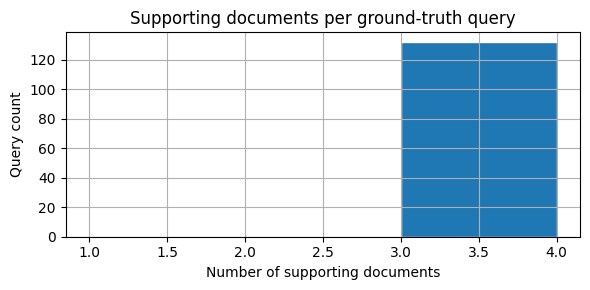

In [16]:
# Number of supporting docs per query
ground_truth["n_supporting"] = ground_truth["supporting_documents"].apply(len)

print("Supporting documents per query:")
print(ground_truth["n_supporting"].value_counts().sort_index().to_string())

fig, ax = plt.subplots(figsize=(6, 3))
ground_truth["n_supporting"].hist(bins=range(1, ground_truth["n_supporting"].max() + 2), ax=ax, edgecolor="white")
ax.set_xlabel("Number of supporting documents")
ax.set_ylabel("Query count")
ax.set_title("Supporting documents per ground-truth query")
plt.tight_layout()
plt.show()

In [ ]:
# Check that all supporting doc IDs exist in corpus
corpus_ids = set(corpus["id"])
all_supporting = {doc_id for docs in ground_truth["supporting_documents"] for doc_id in docs}

missing = all_supporting - corpus_ids
print(f"Unique supporting doc IDs referenced: {len(all_supporting)}")
print(f"Corpus doc IDs available:             {len(corpus_ids)}")
print(f"Supporting IDs missing from corpus:   {len(missing)}")
if missing:
    print("Missing:", missing)

## Chunking strategy recommendation

Summarise what chunk_size=500 actually means for this corpus.

In [ ]:
p25, p50, p75, p95 = corpus["text_len"].quantile([0.25, 0.50, 0.75, 0.95])

print("Corpus text length percentiles:")
print(f"  p25 = {p25:.0f} chars")
print(f"  p50 = {p50:.0f} chars  (median)")
print(f"  p75 = {p75:.0f} chars")
print(f"  p95 = {p95:.0f} chars")
print()

pct_under = 100 * (corpus["text_len"] <= CHUNK_SIZE).mean()
print(f"With chunk_size={CHUNK_SIZE}: {pct_under:.1f}% of docs are passed through as a single chunk.")
print(f"Effective chunking only applies to the {100-pct_under:.1f}% of docs longer than {CHUNK_SIZE} chars.")
print()
if p95 < CHUNK_SIZE:
    print("► Even p95 is below chunk_size — virtually no splitting occurs. "
          "Consider setting chunk_size closer to the median or disabling chunking entirely (chunking: null).")
elif p50 < CHUNK_SIZE:
    print("► Median is below chunk_size — most docs are passed through unsplit. "
          "The fixed strategy only affects the longer tail.")